# Student Health Risk Prediction
## EDA (Exploratory Data Analysis)

Objective

The objective of this notebook is to understand the dataset,
 evaluate data quality, explore feature distribution,
 and identify insights that may help improve predictive modeling.

In [27]:
# import all import python libraries
import numpy as np
import pandas as pd
 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use("default")
pd.set_option("display.max_columns", None)

### Load Data

In [28]:

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
sample = pd.read_csv("../data/sample_submission.csv")

### Dataset Understanding

#### Can the dataset be used directly?

In [29]:
print("Train shape: ", train.shape)
print("test shape: ", test.shape)

Train shape:  (690088, 15)
test shape:  (295753, 14)


In [30]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [31]:
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


### 2. Is the dataset structurally valid?

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [33]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       295753 non-null  int64  
 1   sleep_duration           263182 non-null  float64
 2   heart_rate               292396 non-null  float64
 3   bmi                      289797 non-null  float64
 4   calorie_expenditure      273101 non-null  float64
 5   step_count               289789 non-null  float64
 6   exercise_duration        292795 non-null  float64
 7   water_intake             277120 non-null  float64
 8   diet_type                292795 non-null  object 
 9   stress_level             260263 non-null  object 
 10  sleep_quality            270754 non-null  object 
 11  physical_activity_level  280058 non-null  object 
 12  smoking_alcohol          283504 non-null  object 
 13  gender                   286593 non-null  object 
dtypes: f

In [34]:
# Compare the column between the ship and the inspection — identify discrepancies as expected.
cols_train = set(train.columns)
cols_test = set(test.columns)
 
print('This column is only found on trains:', cols_train - cols_test)
print('This column is only found on test :', cols_test - cols_train)

This column is only found on trains: {'health_condition'}
This column is only found on test : set()


### 3. Is the identifier relible?

In [35]:
print('train id unique:', train['id'].is_unique)
print('test id unique :', test['id'].is_unique)
print('id duplicate between train và test:', len(set(train['id']) & set(test['id'])))

train id unique: True
test id unique : True
id duplicate between train và test: 0


### 4. Does the dataset contain duplicate records?

In [36]:
train.duplicated().sum()

np.int64(0)

### 5. What does the target variable look like?

In [37]:
print(train['health_condition'].value_counts())
print()
print(train['health_condition'].value_counts(normalize=True).round(4) * 100)
# -> Check the % values to see whether the target is imbalanced.
#    Imbalance affects which evaluation metric and validation strategy to use later.

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

health_condition
at-risk      85.87
unhealthy     8.36
fit           5.77
Name: proportion, dtype: float64


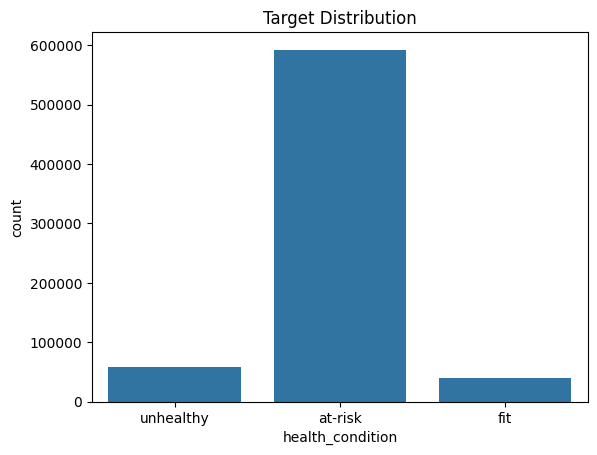

In [38]:
sns.countplot(
    data=train,
    x="health_condition"
)
plt.title("Target Distribution")
plt.show()

### 6. How serious are the missing values?

In [39]:
missing = train.isnull().sum()
missing_pct = (train.isnull().mean() * 100).round(2)
 
missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)
 
missing_summary

,missing_count,missing_pct
stress_level,82811,12.00
sleep_duration,75999,11.01
sleep_quality,58331,8.45
calorie_expenditure,52853,7.66
water_intake,43477,6.30
physical_activity_level,36621,5.31
smoking_alcohol,28582,4.14
gender,21373,3.10
step_count,13916,2.02
bmi,13898,2.01


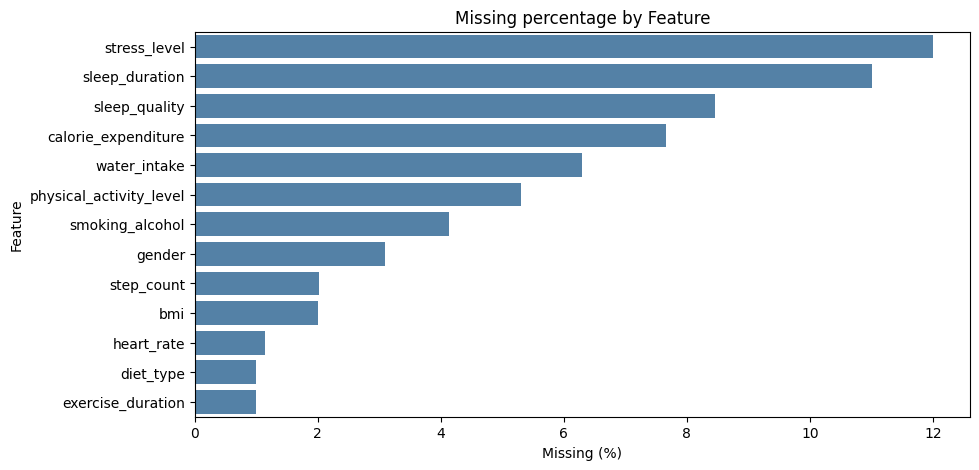

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    data = missing_summary.reset_index(),
    x ="missing_pct",
    y= "index",
    color="steelblue"
)
plt.title("Missing percentage by Feature")
plt.xlabel("Missing (%)")
plt.ylabel("Feature")
plt.show()

In [41]:
# Missing pattern theo target — dấu hiệu MNAR (missing not at random)
# Nếu tỷ lệ missing của 1 biến khác nhau rõ rệt giữa các nhóm target,
# nghĩa là việc thiếu dữ liệu không ngẫu nhiên -> cần ghi chú cho bước Preprocessin
cols_with_missing = missing_summary.index.tolist()
 
missing_by_target = pd.DataFrame({
    col: train[col].isnull().groupby(train['health_condition']).mean().round(4)
    for col in cols_with_missing
}).T
 
missing_by_target


health_condition,at-risk,fit,unhealthy
stress_level,0.1200,0.1196,0.1199
sleep_duration,0.1102,0.1094,0.1097
sleep_quality,0.0846,0.0853,0.0831
calorie_expenditure,0.0765,0.0770,0.0769
water_intake,0.0627,0.0634,0.0654
physical_activity_level,0.0531,0.0526,0.0529
smoking_alcohol,0.0413,0.0414,0.0424
gender,0.0310,0.0299,0.0319
step_count,0.0202,0.0199,0.0195
bmi,0.0208,0.0286,0.0071


In [42]:
# Check nhanh: có cặp cột nào missing đúng cùng 1 tập dòng không
# (gợi ý: exercise_duration và diet_type từng có cùng số lượng missing)
from itertools import combinations
 
for col_a, col_b in combinations(cols_with_missing, 2):
    idx_a = set(train[train[col_a].isnull()].index)
    idx_b = set(train[train[col_b].isnull()].index)
    if idx_a and idx_a == idx_b:
        print(f'{col_a} và {col_b} missing TRÙNG HOÀN TOÀN cùng 1 tập dòng ({len(idx_a)} dòng)')
 

### 7. Are numerical variables within reasonable ranges?

In [43]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', numeric_cols)

train[numeric_cols].describe().T

Numeric columns: ['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']


,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


In [44]:
# Range check thủ công theo hiểu biết miền (domain knowledge) — điều chỉnh ngưỡng nếu cần
checks = {
    'sleep_duration': (0, 24),        # giờ/đêm
    'heart_rate': (30, 220),          # bpm, sinh lý người
    'bmi': (10, 60),
    'calorie_expenditure': (0, None),
    'step_count': (0, None),
    'exercise_duration': (0, None),   # phút
    'water_intake': (0, None),        # lít
}
 
for col, (lo, hi) in checks.items():
    if col not in train.columns:
        continue
    n_low = (train[col] < lo).sum() if lo is not None else 0
    n_high = (train[col] > hi).sum() if hi is not None else 0
    if n_low or n_high:
        print(f'{col}: {n_low} dòng < {lo}, {n_high} dòng > {hi}')
    else:
        print(f'{col}: OK, nằm trong khoảng hợp lý [{lo}, {hi}]')
 

sleep_duration: OK, nằm trong khoảng hợp lý [0, 24]
heart_rate: OK, nằm trong khoảng hợp lý [30, 220]
bmi: OK, nằm trong khoảng hợp lý [10, 60]
calorie_expenditure: OK, nằm trong khoảng hợp lý [0, None]
step_count: OK, nằm trong khoảng hợp lý [0, None]
exercise_duration: OK, nằm trong khoảng hợp lý [0, None]
water_intake: OK, nằm trong khoảng hợp lý [0, None]


### 8. Are categorical variables clean and consistent?

In [45]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)
 
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(train[col].value_counts(dropna=False))
 

Categorical columns: ['health_condition', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

--- health_condition ---
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

--- diet_type ---
diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

--- stress_level ---
stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

--- sleep_quality ---
sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

--- physical_activity_level ---
physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

--- smoking_alcohol ---
smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

--- gender ---
ge

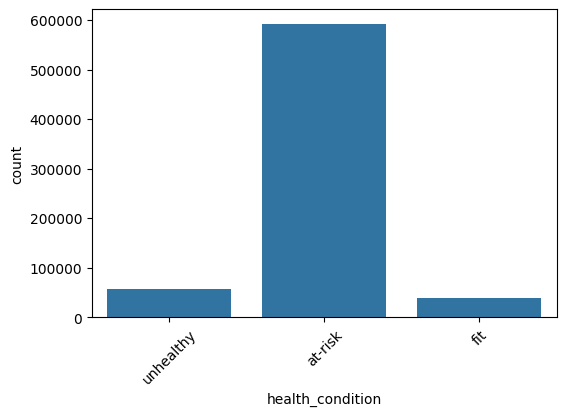

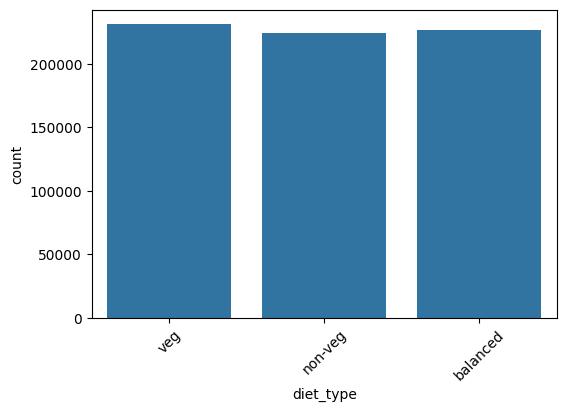

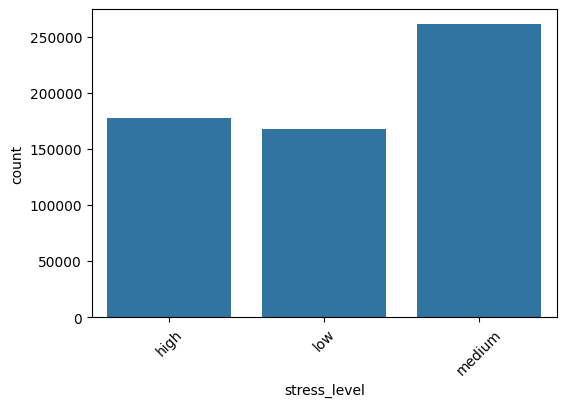

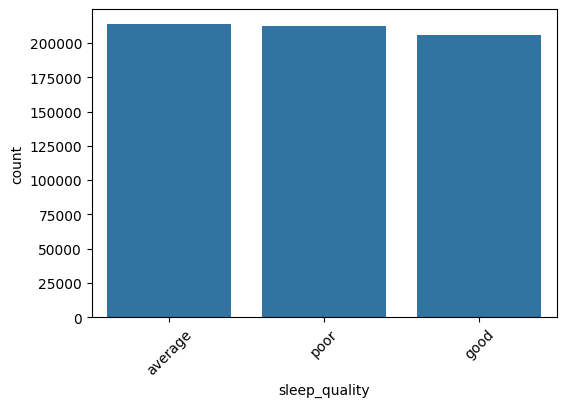

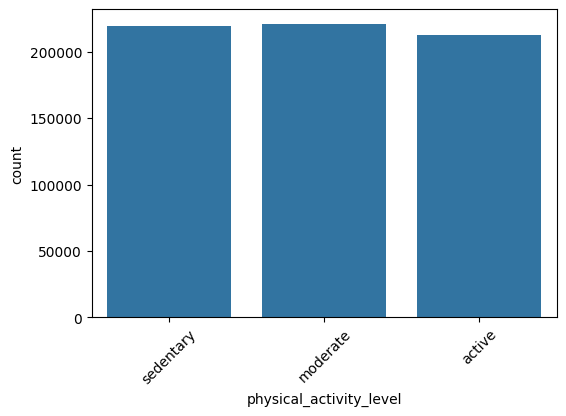

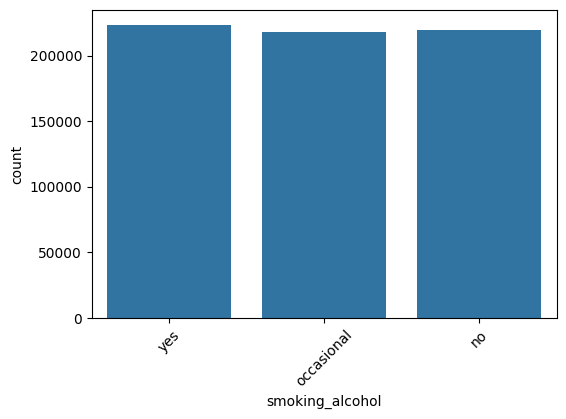

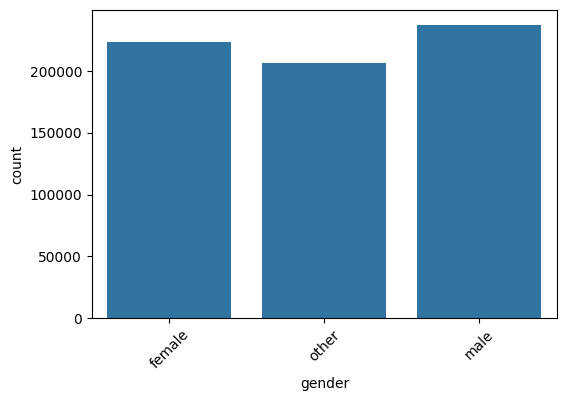

In [46]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(
        data = train,
        x = col
    )
    plt.xticks(rotation = 45)
    plt.show()

In [47]:
# So sánh category giữa train và test — phát hiện category "lạ" chỉ xuất hiện ở 1 bên
# (nếu có, model sau này cần xử lý category không thấy trong lúc train)
shared_cat_cols = [c for c in cat_cols if c in test.columns]
 
for col in shared_cat_cols:
    train_vals = set(train[col].dropna().unique())
    test_vals = set(test[col].dropna().unique())
    diff = (train_vals - test_vals) | (test_vals - train_vals)
    if diff:
        print(f'{col}: có category lệch giữa train/test -> {diff}')
    else:
        print(f'{col}: category khớp hoàn toàn giữa train và test')
 

diet_type: category khớp hoàn toàn giữa train và test
stress_level: category khớp hoàn toàn giữa train và test
sleep_quality: category khớp hoàn toàn giữa train và test
physical_activity_level: category khớp hoàn toàn giữa train và test
smoking_alcohol: category khớp hoàn toàn giữa train và test
gender: category khớp hoàn toàn giữa train và test


### 9. Are there relationships among numerical features?

In [48]:
corr = train[numeric_cols].corr()
corr

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
id,1.000000,-0.001340,-0.001008,-0.000095,-0.000917,0.000155,-0.000883,0.001147
sleep_duration,-0.001340,1.000000,-0.005183,-0.074576,-0.004075,0.004082,0.001708,0.000519
heart_rate,-0.001008,-0.005183,1.000000,0.000612,-0.003967,-0.005486,-0.005679,0.000192
bmi,-0.000095,-0.074576,0.000612,1.000000,0.117624,-0.020548,-0.020289,0.000638
calorie_expenditure,-0.000917,-0.004075,-0.003967,0.117624,1.000000,0.400102,0.393592,0.001534
step_count,0.000155,0.004082,-0.005486,-0.020548,0.400102,1.000000,0.438236,-0.000588
exercise_duration,-0.000883,0.001708,-0.005679,-0.020289,0.393592,0.438236,1.000000,0.002199
water_intake,0.001147,0.000519,0.000192,0.000638,0.001534,-0.000588,0.002199,1.000000


Text(0.5, 1.0, 'Correlation Matrix of Numerical Features')

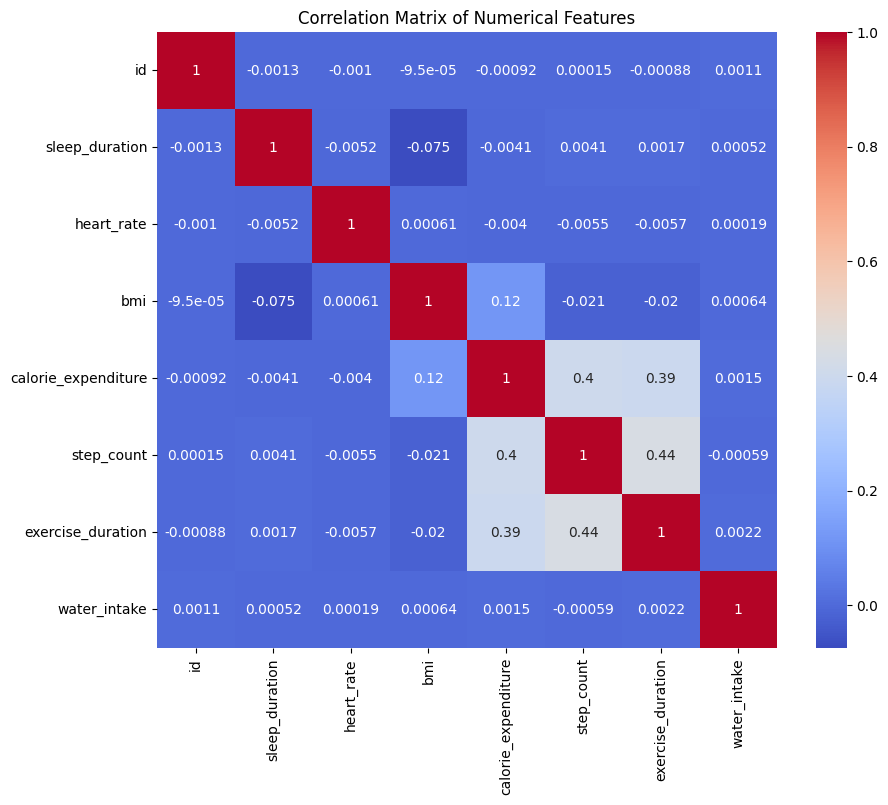

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    train[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix of Numerical Features")

## EXECUTIVE SUMARY
## Dataset Quality

- The dataset contains both numerical and categorical features.
- The `id` column is unique and has been used only as an identifier.
- No duplicate records were found.
- Missing values are present in several features, with the highest missing rate being approximately 12%.
- No invalid values were detected based on the predefined domain constraints.

## Data Understanding

- Numerical and categorical variables have been identified.
- The target variable distribution has been reviewed to understand the prediction task.
- Correlation analysis shows that most numerical features have weak relationships, while exercise duration, calorie expenditure, and step count exhibit moderate positive correlations.

## Key Takeaways

- The dataset has good overall quality and is suitable for further analysis.
- Missing values should be handled during preprocessing instead of EDA.
- Domain validation indicates that numerical variables fall within reasonable ranges.
- Initial correlation analysis provides useful insights but does not imply causation.

## Next Step

The next notebook (**02_Research_Questions.ipynb**) will explore domain-specific questions to better understand the relationships between students' lifestyle and health before moving to feature engineering and predictive modeling.
